In [12]:
import numpy as np
import pandas as pd
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import os
import random
import sys
from PIL import Image, ImageOps
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold, StratifiedKFold

import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import glob
import cv2
from torch.amp import GradScaler, autocast
import timm
import sys
from scipy import signal
from scipy.signal import envelope
from scipy.signal import find_peaks
from scipy import interpolate


In [13]:
# !pip install wandb

In [14]:
import wandb
wandb.login(key="5fedfbd12263ab2d07b8e3acd75745f2c6555562")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
def process_data(data, is_train):   
    a = np.squeeze(np.array(data))
    if is_train:
        a = a*np.random.uniform(0.95, 1.05)
    
    sos = signal.butter(2, 80, 'high', fs=900, output='sos')
    f = signal.sosfilt(sos, a[:])[100:-100]
    f = f / (max(f)-min(f))
    
    sos = signal.butter(2, 60, 'high', fs=900, output='sos')
    f2 = signal.sosfilt(sos, a[:])[100:-100]

    sos = signal.butter(2, 10, 'low', fs=900, output='sos')
    f3 = signal.sosfilt(sos, a[:])[100:-100]
    
    _, e = envelope(abs(f/(max(f)-min(f))), bp_in=[30, 80])
    p, _ = find_peaks(np.squeeze(e), prominence=0.05, width=30)
    
    lp = p[0]
    hp = p[-1]
    while (e[lp]>0.02):
        lp -= 1
    
    while (e[hp]>0.02):
        hp += 1
    
    w = int((lp+hp)/2)
    ww = int((hp-lp)/2)
    if is_train:
        w = w + random.randint(-10, 10)
    
    u0 = f2[w-ww:w+ww]/1250
    u1 = f2[w-450:w+450]/1250
    u2 = f3[w-450:w+450]/1250
    u2 = (u2-min(u2))/(max(u2)-min(u2))
    
    x_old = np.linspace(0, 1, num=u0.size)
    x_new = np.linspace(0, 1, num=800)
    
    f_sample = interpolate.interp1d(x_old, u0, kind='linear')
    uu0 = f_sample(x_new)
    
    fr, t, z1 = signal.stft(uu0, 100, nperseg=100)
    z1 = np.abs(z1)
    i0= Image.fromarray((z1*255).astype(np.uint8), mode='L')
    i0 = np.array(i0.resize((256, 256)))
    
    
    fr, t, z = signal.stft(u1, 900, nperseg=60)
    z = np.abs(z)
    i1 = Image.fromarray((z*255).astype(np.uint8), mode='L')
    i1 = np.array(i1.resize((256, 256)))


    i2 = np.tile(u2, (256, 1))
    i2 = Image.fromarray((i2*255).astype(np.uint8), mode='L')
    i2 = np.array(i2.resize((256, 256)))

    image = np.array([i0, i1, i2])
    # image = cv2.GaussianBlur(image, (3, 3), 0)
    
    return image
    
def transform_data(data, is_train):
    data = process_data(data, is_train)
    return data

    
class d(Dataset):
    def __init__(self, root_dir, csv_file, is_train):
        self.root = root_dir
        self.csv  = csv_file
        self.is_train = is_train
        
    def __getitem__(self, index):
        s = self.csv.iloc[index, 0]
        s = s.replace('\\', '/')
        file     = glob.glob(str('/kaggle/input/map-voice9/DATASET/' + s))[0]
        raw_x    = pd.read_csv(file, header=None).values
        try:
            x_tensor = transform_data(raw_x, self.is_train)
        except: 
            print(file)
        label = int(self.csv.iloc[index, 1])
        output = torch.nn.functional.one_hot(torch.tensor(label), num_classes=20)
        return x_tensor, output

    
    def __len__(self):
        return len(self.csv)

In [16]:
import torch.nn as nn

class VNet(nn.Module):
    def __init__(self, model):
        super(VNet, self).__init__()
        self.model = timm.create_model(model, pretrained=True)
        self.fc0 = nn.Linear(self.model.classifier.out_features, 1024)
        self.fc1 = nn.Linear(1024, 256)   
        self.fc2 = nn.Linear(256, 20)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, image):
        x = image 
        x = self.model(image)
        x = self.fc0(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

def reset_weights(model):
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()


In [17]:
def save_checkpoint(state, filename):
    print('--> Saving checkpoint')
    torch.save(state, filename)
    
def load_checkpoint(checkpoint, model):
    # print('--> Loading checkpoint')
    model.load_state_dict(checkpoint['state_dict'])

In [18]:
NE = 60
BS = 20
max_lr = 1e-4
w_decay = 1e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
weights = torch.tensor([1]).to(DEVICE)

TRAIN_DIR = ''
TEST_DIR  = ''

model_nm = "efficientnet_b0"
model    = VNet(model_nm).to(DEVICE)

# from torchsummary import summary
# summary(model, input_size=(3, 64, 64))
# timm.list_models(pretrained=True)

In [19]:
def eval_net(model, eval_f, is_train):
    model.eval()
    eval_ds     = d(TEST_DIR, eval_f, 0)
    eval_loader = DataLoader(eval_ds, batch_size=BS, shuffle=False)
    
    Loss = []
    Targets = []
    Pred = []
    
    for x,y in tqdm(eval_loader):
        x  = x.to(DEVICE).to(torch.float32)
        y  = y.to(torch.float).to(DEVICE)

        pred = model(x)
        
        criterion = nn.CrossEntropyLoss()
        loss = criterion(pred, y)
        Loss.append(loss)
        Pred.append(pred)
        Targets.append(y.cpu().numpy())
    
    Targets = np.concatenate(Targets)
    Pred = torch.cat(Pred).detach().cpu().numpy()
    label = []
    prediction = []
    q = 0
    for i in range(len(Pred)):
        label.append(np.argmax(Targets[i]).item())
        prediction.append(np.argmax(Pred[i]).item())
        if (torch.argmax(torch.as_tensor(Targets[i])).item() 
            == torch.argmax(torch.as_tensor(Pred[i])).item()):
            q += 1
    print(f'Accuracy: {q/len(Targets)}')
    if is_train == 1:
        wandb.log({"Train Accuracy": q/len(Targets)})
    if is_train == 0:
        wandb.log({"Test Accuracy": q/len(Targets)})
    return label, prediction

In [20]:
def eval(model, eval_f, is_train):
    model.eval()
    eval_ds     = d(TEST_DIR, eval_f, 0)
    eval_loader = DataLoader(eval_ds, batch_size=BS, shuffle=False)
    
    Loss = []
    Targets = []
    Pred = []
    
    for x,y in tqdm(eval_loader):
        x  = x.to(DEVICE).to(torch.float32)
        y  = y.to(torch.float).to(DEVICE)

        pred = model(x)
        
        criterion = nn.CrossEntropyLoss()
        loss = criterion(pred, y)        
        Loss.append(loss)
        Pred.append(pred)
        Targets.append(y.cpu().numpy())
    
    Targets = np.concatenate(Targets)
    Pred = torch.cat(Pred).detach().cpu().numpy()
    q = 0
    for i in range(len(Targets)):
        if (torch.argmax(torch.as_tensor(Targets[i])).item() 
            == torch.argmax(torch.as_tensor(Pred[i])).item()):
            q += 1
    print(f'Accuracy: {q/len(Targets)}')
    

In [21]:
def train_net(model, train_f, eval_f, fold):
    loss_ = 9e9
    optimizer = torch.optim.Adam(model.parameters(), lr=max_lr, weight_decay=w_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=max_lr, epochs=NE,
                                                    steps_per_epoch=int(len(train_f)/BS)+1, pct_start=0.3)
    scaler = GradScaler()
    reset_weights(model)
    for epoch in range(NE):
        print('Epoch: ' + str(epoch))
        model.train()
        train_ds     = d(TRAIN_DIR, train_f, 1)
        train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True)
        for x,y in tqdm(train_loader):
            optimizer.zero_grad()
            x  = x.to(DEVICE).to(torch.float32)
            y  = y.to(torch.float).to(DEVICE)
            with autocast(DEVICE):
                pred = model(x)
                criterion = nn.CrossEntropyLoss()
                loss = criterion(pred, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            
            scheduler.step()
            scaler.update()
            
            LR = scheduler.get_last_lr()[0]
            # LR = max_lr
            wandb.log({"loss": loss.item(), "lr":LR})
        
        
        with torch.no_grad():
            eval_net(model, train_f, 1)
            eval_net(model, eval_f, 0)
        # eval_net(model, eval_f)
        # eval(model, Test_csv)
    with torch.no_grad():
        T, P = eval_net(model, eval_f, -1)
    checkpoint = {
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict()
    }
    save_checkpoint(checkpoint, f'F{fold}-epoch{epoch}.pth')
    return T, P

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Train_csv_B = pd.read_csv('/kaggle/input/map-voice9/DATASET/Data6/all.csv').iloc()[:]
Train_csv_N = pd.read_csv('/kaggle/input/map-voice9/DATASET/Data7/all.csv').iloc()[:]

XB = Train_csv_B.drop(columns=["label"])
yB = Train_csv_B["label"]
XN = Train_csv_N.drop(columns=["label"])
yN = Train_csv_N["label"]
Tset = []
Pset = []

B_folds = list(kf.split(XB, yB))
N_folds = list(kf.split(XN, yN))

for fold in range(5):
    train_idxB, test_idxB = B_folds[fold]
    train_idxN, test_idxN = N_folds[fold]

    trainB = Train_csv_B.iloc[train_idxB]
    testB  = Train_csv_B.iloc[test_idxB]

    trainN = Train_csv_N.iloc[train_idxN]
    testN  = Train_csv_N.iloc[test_idxN]

    train_df = pd.concat([trainB, trainN], ignore_index=True)
    test_df  = pd.concat([testB, testN], ignore_index=True)

    with wandb.init(project="[MAP03]", name=f'FULL_RANGE_lm_LR_{max_lr}_w_decay{w_decay}_BS_{BS}_NE_{NE}_fold_{fold}') as run:
        wandb.watch(model)
        model    = VNet(model_nm).to(DEVICE)
        T, P = train_net(model, train_df, test_df, fold)
        for i in range(len(T)):
            Tset.append(T[i])
            Pset.append(P[i])
D_Tset = pd.DataFrame(Tset)
D_Tset.to_csv('Tset.csv')

D_Pset = pd.DataFrame(Pset)
D_Pset.to_csv('Pset.csv')

Epoch: 0


100%|██████████| 51/51 [00:10<00:00,  5.09it/s]


Accuracy: 0.05583250249252243


100%|██████████| 13/13 [00:02<00:00,  5.11it/s]


Accuracy: 0.047619047619047616
Epoch: 1


...

100%|██████████| 13/13 [00:02<00:00,  4.90it/s]


Accuracy: 0.892


100%|██████████| 13/13 [00:02<00:00,  4.98it/s]


Accuracy: 0.892
--> Saving checkpoint


Test Accuracy,▁▂▂▂▃▄▄▅▆▆▇▇▇▇▇▇▇▇██████████████████████
Train Accuracy,▁▁▂▂▃▃▃▄▆▆▇▇▇███████████████████████████
loss,█████▅▄▅▄▄▄▃▂▂▁▁▁▂▁▂▃▁▁▁▁▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁
lr,▁▁▁▂▂▂▂▃▅▅████▇▇▇▆▆▆▅▅▅▅▅▅▅▄▄▃▃▂▂▂▁▁▁▁▁▁
Test Accuracy,0.892
Train Accuracy,0.99502
loss,2.08218
lr,0.0


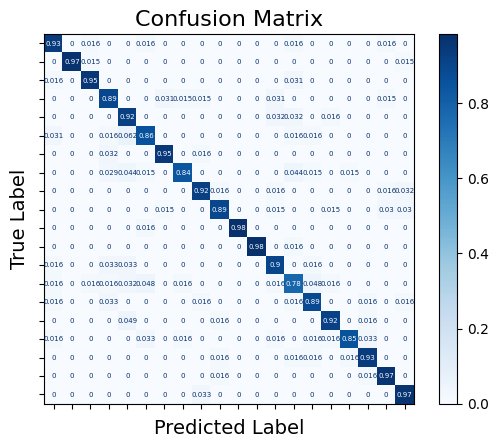

In [23]:
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions(Tset, Pset, cmap=plt.cm.Blues, display_labels=[], normalize='true')
# Adjust text size
plt.xticks(fontsize=12)  # Modify x-axis label size
plt.yticks(fontsize=12)  # Modify y-axis label size

# If you want to update the title or axis labels

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
for text in disp.ax_.texts:
    text.set_fontsize(5)
# Show the plot
plt.savefig("confusion_matrix0.png", dpi=500, bbox_inches='tight')
plt.show()


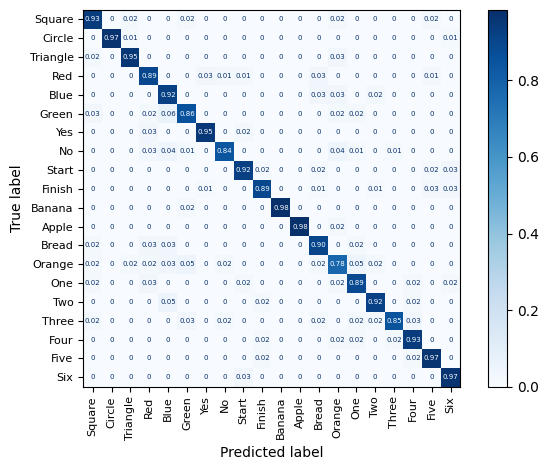

In [24]:
# Tset = pd.read_csv('/kaggle/input/map-eff256/eff256/Tset.csv').iloc()[:, 1]
# Pset = pd.read_csv('/kaggle/input/map-eff256/eff256/Pset.csv').iloc()[:, 1]

Tset = pd.read_csv('Tset.csv').iloc()[:, 1]
Pset = pd.read_csv('Pset.csv').iloc()[:, 1]
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
class_labels = ['Square', 'Circle', 'Triangle',
       'Red', 'Blue', 'Green', 
       'Yes', 'No', 'Start', 'Finish', 
       'Banana', 'Apple', 'Bread', 'Orange',
       'One', 'Two', 'Three', 'Four', 'Five', 'Six']
disp = ConfusionMatrixDisplay.from_predictions(Tset, Pset, cmap=plt.cm.Blues, display_labels=class_labels, normalize='true')
# Adjust text size

plt.xticks(fontsize=8)  # Modify x-axis label size
plt.yticks(fontsize=8)  # Modify y-axis label size

plt.xticks(rotation=90)

# If you want to update the title or axis labels

# plt.xlabel("Predicted Label", fontsize=14)
# plt.ylabel("True Label", fontsize=14)
# plt.title("Confusion Matrix", fontsize=16)
for text in disp.ax_.texts:
    value = float(text.get_text())
    if value == 0.0:
        text.set_text("0")
    else:
        text.set_text(f"{value:.2f}")
    text.set_fontsize(5)

# Show the plot
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=800, bbox_inches='tight') 
plt.show()



In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Tset, Pset)
print(f"Mean Accuracy: {accuracy:.4f}")

Mean Accuracy: 0.9147
